# Baseline de Recomendação - RetailRocket

Este notebook implementa e avalia baselines de recomendação top-K para o dataset
RetailRocket com feedback implícito. O objetivo é estabelecer referências de
performance para modelos futuros (MLP), garantindo reprodutibilidade e
validação por qualquer membro do grupo.

**Decisões técnicas herdadas do EDA:**

- Split cronológico 70/15/15 (sem vazamento temporal)
- Pesos implícitos: `view=1`, `addtocart=3`, `transaction=5`
- Target: `addtocart` OU `transaction` (sinal positivo)
- Cold-start tratado com MostPopular como fallback
- Item-KNN limitado aos 20K itens mais populares para viabilidade

**Estrutura:**

1. Setup e configuração
2. Carga e inspeção dos dados
3. Pesos implícitos e target
4. Split cronológico
5. Matriz usuário-item esparsa
6. Ground truth de avaliação
7. Baseline MostPopular
8. Baseline Item-KNN
9. Framework de métricas
10. Avaliação dos baselines
11. Análise cold-start
12. Testes inline de validação
13. Visualizações comparativas
14. Resultados consolidados
15. Conclusões e próximos passos
16. Exemplo de uso
17. Exemplo de recomendação por usuário

## 0. Setup e configuração

Parâmetros configuráveis via variáveis de ambiente.
Os CSVs são procurados em `data/` por padrao.

In [93]:
from __future__ import annotations

import os
import time
from collections import defaultdict
from pathlib import Path
from typing import Optional

%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import scipy.sparse as sp
from IPython.display import Markdown, display
from sklearn.metrics.pairwise import cosine_similarity

# --- Parâmetros configuráveis ---
RANDOM_SEED = int(os.environ.get("RANDOM_SEED", "42"))
TOP_K = [5, 10, 20]
IMPLICIT_WEIGHTS = {"view": 1, "addtocart": 3, "transaction": 5}
SESSION_GAP_MIN = 30
SPLIT_RATIOS = (0.70, 0.15, 0.15)
K_NEIGHBORS = 50
MAX_SIM_ITEMS = 20_000
MAX_EVAL_USERS = 5_000

# --- Caminhos ---
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = Path(
    os.environ.get("RETAILROCKET_DATA_DIR", PROJECT_ROOT / "data")
).expanduser()

events_path = DATA_DIR / "events.csv"
category_tree_path = DATA_DIR / "category_tree.csv"
item_property_paths = [
    DATA_DIR / "item_properties_part1.csv",
    DATA_DIR / "item_properties_part2.csv",
]

csv_paths = [events_path, category_tree_path, *item_property_paths]
missing_files = [p.name for p in csv_paths if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        f"CSV(s) não encontrados: {', '.join(missing_files)}. "
        f"Ajuste RETAILROCKET_DATA_DIR ou coloque os arquivos em data/."
    )

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

print(f"DATA_DIR: {DATA_DIR}")
print(f"RANDOM_SEED: {RANDOM_SEED}")
print(f"IMPLICIT_WEIGHTS: {IMPLICIT_WEIGHTS}")
print(f"TOP_K: {TOP_K}")
print(f"SPLIT_RATIOS: {SPLIT_RATIOS}")
print(f"K_NEIGHBORS: {K_NEIGHBORS}")
print(f"MAX_SIM_ITEMS: {MAX_SIM_ITEMS}")
print(f"MAX_EVAL_USERS: {MAX_EVAL_USERS}")

DATA_DIR: /Users/ed/Developer/Learn/MLEngineer/Repos/tech-challenge-fase-2/.worktrees/issue-23-realizar-eda-do-dataset-retailrocket-ecommerce/data
RANDOM_SEED: 42
IMPLICIT_WEIGHTS: {'view': 1, 'addtocart': 3, 'transaction': 5}
TOP_K: [5, 10, 20]
SPLIT_RATIOS: (0.7, 0.15, 0.15)
K_NEIGHBORS: 50
MAX_SIM_ITEMS: 20000
MAX_EVAL_USERS: 5000


## 1. Carga e inspeção dos dados

Carrega `events.csv` com conversão de timestamps e inspeção básica.

In [94]:
events = pd.read_csv(events_path)
events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms", utc=True)
events = events.sort_values(["event_time", "visitorid", "itemid"]).reset_index(
    drop=True
)

inspeção = pd.DataFrame(
    {
        "metrica": [
            "total_eventos",
            "visitors_unicos",
            "itens_unicos",
            "periodo_inicio",
            "periodo_fim",
            "view_pct",
            "addtocart_pct",
            "transaction_pct",
        ],
        "valor": [
            f"{len(events):,}",
            f"{events['visitorid'].nunique():,}",
            f"{events['itemid'].nunique():,}",
            str(events["event_time"].min()),
            str(events["event_time"].max()),
            f"{(events['event'] == 'view').mean():.2%}",
            f"{(events['event'] == 'addtocart').mean():.2%}",
            f"{(events['event'] == 'transaction').mean():.2%}",
        ],
    }
)
display(inspeção)
display(events.head())

,metrica,valor
0,total_eventos,"2,756,101"
1,visitors_unicos,"1,407,580"
2,itens_unicos,"235,061"
3,periodo_inicio,2015-05-03 03:00:04.384000+00:00
4,periodo_fim,2015-09-18 02:59:47.788000+00:00
5,view_pct,96.67%
6,addtocart_pct,2.52%
7,transaction_pct,0.81%


,timestamp,visitorid,event,itemid,transactionid,event_time
0,1430622004384,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384000+00:00
1,1430622011289,829044,view,60987,NaN,2015-05-03 03:00:11.289000+00:00
2,1430622013048,652699,view,252860,NaN,2015-05-03 03:00:13.048000+00:00
3,1430622024154,1125936,view,33661,NaN,2015-05-03 03:00:24.154000+00:00
4,1430622026228,693516,view,297662,NaN,2015-05-03 03:00:26.228000+00:00


## 2. Pesos implícitos e target

Atribui pesos por tipo de evento conforme decisão do EDA: `view=1`, `addtocart=3`,
`transaction=5`. O target binário é 1 para `addtocart` ou `transaction`.

In [95]:
events["implicit_weight"] = events["event"].map(IMPLICIT_WEIGHTS).fillna(0).astype(int)
events["target"] = events["event"].isin(["addtocart", "transaction"]).astype(int)

# Validação: nenhum peso zero para eventos conhecidos
assert (
    events.loc[events["event"].isin(IMPLICIT_WEIGHTS), "implicit_weight"].min() > 0
), "Erro: eventos conhecidos com peso zero."

weight_dist = (
    events.groupby("event")["implicit_weight"].agg(["count", "mean"]).reset_index()
)
display(weight_dist)

target_counts = events["target"].value_counts()
n_positivo = int(target_counts.get(1, 0))
n_negativo = int(target_counts.get(0, 0))
display(
    Markdown(
        f"**Target positivo (addtocart ou transaction):** "
        f"{n_positivo:,} eventos ({n_positivo / len(events):.2%})  |  "
        f"Negativo: {n_negativo:,} eventos ({n_negativo / len(events):.2%})"
    )
)

,event,count,mean
0,addtocart,69332,3.0
1,transaction,22457,5.0
2,view,2664312,1.0


**Target positivo (addtocart ou transaction):** 91,789 eventos (3.33%)  |  Negativo: 2,664,312 eventos (96.67%)

## 3. Split cronológico

Divisao temporal 70/15/15 sem sobreposição. Nenhum evento futuro é usado como feature.

In [96]:
time_min = events["event_time"].min()
time_max = events["event_time"].max()
time_range = time_max - time_min

train_end = time_min + time_range * SPLIT_RATIOS[0]
val_end = train_end + time_range * SPLIT_RATIOS[1]

train_df = events[events["event_time"] < train_end].copy()
val_df = events[
    (events["event_time"] >= train_end) & (events["event_time"] < val_end)
].copy()
test_df = events[events["event_time"] >= val_end].copy()

split_summary = pd.DataFrame(
    {
        "partição": ["treino", "validação", "teste"],
        "inicio": [
            train_df["event_time"].min(),
            val_df["event_time"].min(),
            test_df["event_time"].min(),
        ],
        "fim": [
            train_df["event_time"].max(),
            val_df["event_time"].max(),
            test_df["event_time"].max(),
        ],
        "eventos": [len(train_df), len(val_df), len(test_df)],
        "visitors_unicos": [
            train_df["visitorid"].nunique(),
            val_df["visitorid"].nunique(),
            test_df["visitorid"].nunique(),
        ],
        "itens_unicos": [
            train_df["itemid"].nunique(),
            val_df["itemid"].nunique(),
            test_df["itemid"].nunique(),
        ],
    }
)
display(split_summary)

# Validações de split
assert len(train_df) + len(val_df) + len(test_df) == len(events), "Split inconsistente."
assert (
    train_df["event_time"].max() < val_df["event_time"].min()
), "Sobreposição treino/validação."
assert (
    val_df["event_time"].max() < test_df["event_time"].min()
), "Sobreposição validação/teste."

display(Markdown(f"**Corte treino:** {train_end}  |  **Corte validação:** {val_end}"))

,partição,inicio,fim,eventos,visitors_unicos,itens_unicos
0,treino,2015-05-03 03:00:04.384000+00:00,2015-08-07 17:23:51.027000+00:00,2024042,1027985,205106
1,validação,2015-08-07 17:24:01.201000+00:00,2015-08-28 10:11:35.565000+00:00,365683,208377,91507
2,teste,2015-08-28 10:11:57.824000+00:00,2015-09-18 02:59:47.788000+00:00,366376,208236,91400


**Corte treino:** 2015-08-07 17:23:52.766799999+00:00  |  **Corte validação:** 2015-08-28 10:11:50.277399999+00:00

## 4. Matriz usuário-item esparsa

Constroi a matriz esparsa de interações com pesos implícitos usando apenas o
conjunto de treino. Cada célula `(u, i)` contem a soma dos pesos das
interações do usuário `u` com o item `i`.

In [97]:
# Mapear IDs para indices densos
visitor_ids = train_df["visitorid"].unique()
item_ids = train_df["itemid"].unique()

visitor_to_idx = {v: i for i, v in enumerate(visitor_ids)}
item_to_idx = {it: i for i, it in enumerate(item_ids)}
idx_to_item = {i: it for it, i in item_to_idx.items()}
idx_to_visitor = {i: v for v, i in visitor_to_idx.items()}

n_users = len(visitor_ids)
n_items = len(item_ids)

display(Markdown(f"**Matriz treino:** {n_users:,} usuários x {n_items:,} itens"))

# Agregar pesos por (usuário, item)
train_df = train_df.assign(
    visitor_idx=train_df["visitorid"].map(visitor_to_idx),
    item_idx=train_df["itemid"].map(item_to_idx),
)

interaction_weights = (
    train_df.groupby(["visitor_idx", "item_idx"], observed=True)["implicit_weight"]
    .sum()
    .reset_index()
)

# Clipar pesos extremos
interaction_weights["implicit_weight"] = interaction_weights["implicit_weight"].clip(
    upper=50
)

sparse_matrix = sp.csr_matrix(
    (
        interaction_weights["implicit_weight"].values,
        (
            interaction_weights["visitor_idx"].values,
            interaction_weights["item_idx"].values,
        ),
    ),
    shape=(n_users, n_items),
)

sparsity = 1 - sparse_matrix.nnz / (n_users * n_items)
display(
    Markdown(
        f"Esparsidade da matriz: **{sparsity:.6%}**  |  NNZ: {sparse_matrix.nnz:,}"
    )
)

**Matriz treino:** 1,027,985 usuários x 205,106 itens

Esparsidade da matriz: **99.999255%**  |  NNZ: 1,570,409

## 5. Ground truth de avaliação

Para cada usuário no conjunto de validação/teste, os itens com interação positiva
(`addtocart` ou `transaction`) formam o conjunto relevante. Apenas usuários que
também aparecem no treino são avaliados (cold-start é reportado separadamente).

In [98]:
def build_ground_truth(
    df: pd.DataFrame,
    visitor_to_idx: dict,
    item_to_idx: dict,
    min_weight: int = 1,
) -> dict[int, set[int]]:
    """Constroi ground truth: usuario_idx -> conjunto de item_idx relevantes."""
    df_known = df[
        df["visitorid"].isin(visitor_to_idx) & df["itemid"].isin(item_to_idx)
    ].copy()
    df_known["visitor_idx"] = df_known["visitorid"].map(visitor_to_idx)
    df_known["item_idx"] = df_known["itemid"].map(item_to_idx)

    user_item_weight = (
        df_known.groupby(["visitor_idx", "item_idx"], observed=True)["implicit_weight"]
        .sum()
        .reset_index()
    )
    user_item_weight = user_item_weight[
        user_item_weight["implicit_weight"] >= min_weight
    ]

    ground_truth: dict[int, set[int]] = defaultdict(set)
    for _, row in user_item_weight.iterrows():
        ground_truth[int(row["visitor_idx"])].add(int(row["item_idx"]))

    return dict(ground_truth)


val_ground_truth = build_ground_truth(val_df, visitor_to_idx, item_to_idx)
test_ground_truth = build_ground_truth(test_df, visitor_to_idx, item_to_idx)

val_cold = val_df[~val_df["visitorid"].isin(visitor_to_idx)]["visitorid"].nunique()
test_cold = test_df[~test_df["visitorid"].isin(visitor_to_idx)]["visitorid"].nunique()

gt_summary = pd.DataFrame(
    {
        "partição": ["validação", "teste"],
        "usuarios_avaliaveis": [len(val_ground_truth), len(test_ground_truth)],
        "usuarios_cold_start": [val_cold, test_cold],
        "itens_medios_por_usuario": [
            (
                np.mean([len(v) for v in val_ground_truth.values()])
                if val_ground_truth
                else 0
            ),
            (
                np.mean([len(v) for v in test_ground_truth.values()])
                if test_ground_truth
                else 0
            ),
        ],
    }
)
display(gt_summary)

,partição,usuarios_avaliaveis,usuarios_cold_start,itens_medios_por_usuario
0,validação,16922,190534,2.132254
1,teste,12136,195082,1.999258


## 6. Baseline MostPopular

Recomenda os K itens mais populares (por soma de pesos implícitos) para todos os
usuários. Serve como lower bound e fallback para cold-start.

In [99]:
class MostPopularRecommender:
    """Recomenda os itens mais populares por peso implícito agregado."""

    def __init__(self) -> None:
        self.popular_items: np.ndarray = np.array([])
        self.item_scores: np.ndarray = np.array([])

    def fit(self, sparse_mat: sp.csr_matrix) -> "MostPopularRecommender":
        item_scores = np.asarray(sparse_mat.sum(axis=0)).ravel()
        self.item_scores = item_scores
        self.popular_items = np.argsort(-item_scores)
        return self

    def recommend(
        self,
        user_idx: int,
        k: int,
        exclude_seen: bool = True,
        sparse_mat: Optional[sp.csr_matrix] = None,
    ) -> np.ndarray:
        if not exclude_seen or sparse_mat is None:
            return self.popular_items[:k]
        seen = set(sparse_mat[user_idx].nonzero()[1])
        if not seen:
            return self.popular_items[:k]
        mask = ~np.isin(self.popular_items, list(seen))
        filtered = self.popular_items[mask]
        return (
            filtered[:k]
            if len(filtered) >= k
            else np.concatenate([filtered, self.popular_items[: k - len(filtered)]])
        )


most_pop = MostPopularRecommender()
most_pop.fit(sparse_matrix)

top_10_popular = [idx_to_item[i] for i in most_pop.popular_items[:10]]
display(Markdown(f"Top-10 itens mais populares (por peso implícito): {top_10_popular}"))

Top-10 itens mais populares (por peso implícito): [np.int64(461686), np.int64(5411), np.int64(309778), np.int64(370653), np.int64(257040), np.int64(369447), np.int64(7943), np.int64(298009), np.int64(48030), np.int64(335975)]

## 7. Baseline Item-KNN

Recomenda itens por similaridade de cosseno entre vetores de interação de itens.
Para cada usuário, o score de um item candidato é a soma ponderada das
similaridades dos itens com os quais o usuário ja interagiu.

Para viabilidade de memoria, a similaridade é calculada apenas entre os
`MAX_SIM_ITEMS` itens mais populares. Itens fora deste subconjunto recebem
MostPopular como fallback.

In [100]:
class ItemKNNRecommender:
    """Item-KNN com similaridade de cosseno esparsa.

    A recomendação usa multiplicacao de matriz esparsa para vetorizar o
    calculo de scores: scores = user_weights[sim_items] @ sim_matrix,
    mapeando de volta para indices globais.
    """

    def __init__(self, k_neighbors: int = 50, max_sim_items: int = 20_000) -> None:
        self.k_neighbors = k_neighbors
        self.max_sim_items = max_sim_items
        self.sim_matrix: Optional[sp.csr_matrix] = None
        self.popular_items: Optional[np.ndarray] = None
        self.n_items: int = 0
        self.sim_item_indices: Optional[np.ndarray] = None
        self.idx_mapping: Optional[dict] = None

    def fit(self, sparse_mat: sp.csr_matrix) -> "ItemKNNRecommender":
        self.n_items = sparse_mat.shape[1]
        item_popularity = np.asarray(sparse_mat.sum(axis=0)).ravel()
        self.popular_items = np.argsort(-item_popularity)

        # Selecionar top max_sim_items itens para calcular similaridade
        n_sim = min(self.max_sim_items, self.n_items)
        self.sim_item_indices = self.popular_items[:n_sim]

        # Mapeamento de índice global para índice local no subconjunto
        self.idx_mapping = {
            int(global_idx): local_idx
            for local_idx, global_idx in enumerate(self.sim_item_indices)
        }

        # Submatriz: itens x usuários (apenas itens populares)
        X = sparse_mat[:, self.sim_item_indices].T.tocsr().astype(np.float32)

        # Calcular similaridade por blocos para não estourar RAM
        print(f"Calculando similaridade entre {n_sim:,} itens...")
        batch_size = 5000
        n = X.shape[0]
        sim_rows: list[sp.csr_matrix] = []
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch_sim = cosine_similarity(X[start:end], X, dense_output=False)
            sim_rows.append(batch_sim)

        full_sim = sp.vstack(sim_rows, format="csr")

        # Sparsificar: manter apenas top-K vizinhos por linha
        self.sim_matrix = self._sparsify_topk(full_sim, self.k_neighbors)

        print(f"Similaridade calculada. Shape: {self.sim_matrix.shape}")
        return self

    @staticmethod
    def _sparsify_topk(sim: sp.csr_matrix, k: int) -> sp.csr_matrix:
        """Para cada linha, manter apenas os K maiores valores."""
        sim = sim.tocsr().copy()
        for i in range(sim.shape[0]):
            row_start = sim.indptr[i]
            row_end = sim.indptr[i + 1]
            nnz = row_end - row_start
            if nnz > k:
                # argpartition retorna indices relativos ao slice data[row_start:row_end]
                top_k_pos = np.argpartition(sim.data[row_start:row_end], -k)[-k:]
                mask = np.zeros(nnz, dtype=bool)
                mask[top_k_pos] = True
                sim.data[row_start:row_end] = np.where(
                    mask, sim.data[row_start:row_end], 0.0
                )
        sim.eliminate_zeros()
        return sim

    def recommend(
        self,
        user_idx: int,
        k: int,
        exclude_seen: bool = True,
        sparse_mat: Optional[sp.csr_matrix] = None,
    ) -> np.ndarray:
        if sparse_mat is None:
            raise ValueError("sparse_mat e obrigatório para Item-KNN.")

        user_interactions = sparse_mat[user_idx]
        seen_items = set(int(x) for x in user_interactions.nonzero()[1])

        # Cold-start: sem interações, usar MostPopular
        if len(seen_items) == 0:
            candidates = self.popular_items[: k * 2]
            if exclude_seen:
                candidates = [c for c in candidates if c not in seen_items]
            return np.array(candidates[:k])

        # Vetorizar: construir vetor local de pesos do usuário para itens do subconjunto
        local_weights = np.zeros(len(self.sim_item_indices), dtype=np.float32)
        for global_idx in seen_items:
            if global_idx in self.idx_mapping:
                local_idx = self.idx_mapping[global_idx]
                local_weights[local_idx] = user_interactions[0, global_idx]

        # Se nenhum item visto esta no subconjunto, fallback MostPopular
        if local_weights.sum() == 0:
            candidates = self.popular_items[: k * 2]
            if exclude_seen:
                candidates = [c for c in candidates if c not in seen_items]
            return np.array(candidates[:k])

        # Score via multiplicacao esparsa: local_weights (1, n_sim) @ sim_matrix (n_sim, n_sim)
        local_scores = (
            sp.csr_matrix(local_weights).dot(self.sim_matrix).toarray().ravel()
        )

        # Mapear scores locais de volta para indices globais
        scores = np.zeros(self.n_items, dtype=np.float32)
        for local_j, score in enumerate(local_scores):
            if score > 0:
                scores[int(self.sim_item_indices[local_j])] = score

        # Excluir itens ja vistos
        if exclude_seen:
            for s in seen_items:
                scores[s] = -np.inf

        # Se nenhum score positivo, fallback para MostPopular
        if np.max(scores) <= 0:
            candidates = self.popular_items[: k * 2]
            if exclude_seen:
                candidates = [c for c in candidates if c not in seen_items]
            return np.array(candidates[:k])

        return np.argsort(-scores)[:k]


print("Treinando Item-KNN... isso pode levar alguns minutos.")
t0 = time.time()
knn = ItemKNNRecommender(k_neighbors=K_NEIGHBORS, max_sim_items=MAX_SIM_ITEMS)
knn.fit(sparse_matrix)
elapsed = time.time() - t0
print(f"Item-KNN treinado em {elapsed:.1f}s.")

Treinando Item-KNN... isso pode levar alguns minutos.
Calculando similaridade entre 20,000 itens...
Similaridade calculada. Shape: (20000, 20000)
Item-KNN treinado em 0.4s.


## 8. Framework de métricas

Métricas de ranking padronizadas: Precision@K, Recall@K, NDCG@K, HitRate@K.

In [101]:
def precision_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    """Precision@K: fracao dos K recomendados que são relevantes."""
    if k == 0:
        return 0.0
    return len(set(recommended[:k]) & relevant) / k


def recall_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    """Recall@K: fracao dos relevantes que aparecem nos K recomendados."""
    if len(relevant) == 0:
        return 0.0
    return len(set(recommended[:k]) & relevant) / len(relevant)


def ndcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    """NDCG@K: discounted cumulative gain normalizado."""
    if len(relevant) == 0:
        return 0.0
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))
    return dcg / idcg if idcg > 0 else 0.0


def hit_rate_at_k(recommended: list[int], relevant: set[int], k: int) -> int:
    """HitRate@K: 1 se algum relevante esta nos K recomendados, 0 caso contrário."""
    return 1 if set(recommended[:k]) & relevant else 0


def evaluate_recommender(
    recommender,
    ground_truth: dict[int, set[int]],
    sparse_mat: sp.csr_matrix,
    k_values: list[int],
    max_users: Optional[int] = None,
    exclude_seen: bool = True,
) -> pd.DataFrame:
    """Avalia um recommender em métricas de ranking para multiplos K."""
    user_indices = list(ground_truth.keys())
    if max_users and len(user_indices) > max_users:
        rng = np.random.default_rng(RANDOM_SEED)
        user_indices = rng.choice(user_indices, size=max_users, replace=False).tolist()

    results = {
        k: {"precision": [], "recall": [], "ndcg": [], "hit_rate": []} for k in k_values
    }
    max_k = max(k_values)

    for user_idx in user_indices:
        relevant = ground_truth[user_idx]
        if not relevant:
            continue
        try:
            recommended = recommender.recommend(
                user_idx, k=max_k, exclude_seen=exclude_seen, sparse_mat=sparse_mat
            )
            recommended = (
                recommended.tolist()
                if hasattr(recommended, "tolist")
                else list(recommended)
            )
        except Exception:
            continue
        for k in k_values:
            results[k]["precision"].append(precision_at_k(recommended, relevant, k))
            results[k]["recall"].append(recall_at_k(recommended, relevant, k))
            results[k]["ndcg"].append(ndcg_at_k(recommended, relevant, k))
            results[k]["hit_rate"].append(hit_rate_at_k(recommended, relevant, k))

    rows = []
    for k in k_values:
        rows.append(
            {
                "K": k,
                "Precision@K": (
                    np.mean(results[k]["precision"]) if results[k]["precision"] else 0.0
                ),
                "Recall@K": (
                    np.mean(results[k]["recall"]) if results[k]["recall"] else 0.0
                ),
                "NDCG@K": np.mean(results[k]["ndcg"]) if results[k]["ndcg"] else 0.0,
                "HitRate@K": (
                    np.mean(results[k]["hit_rate"]) if results[k]["hit_rate"] else 0.0
                ),
                "n_users": len(results[k]["precision"]),
            }
        )
    return pd.DataFrame(rows)

## 9. Avaliação dos baselines

Avalia MostPopular e Item-KNN nos conjuntos de validação e teste.

In [102]:
display(Markdown("### Avaliação na validação"))
display(Markdown("Executando MostPopular na validação..."))
most_pop_val = evaluate_recommender(
    most_pop, val_ground_truth, sparse_matrix, TOP_K, max_users=MAX_EVAL_USERS
)
most_pop_val["modelo"] = "MostPopular"
display(most_pop_val)

display(Markdown("Executando Item-KNN na validação..."))
knn_val = evaluate_recommender(
    knn, val_ground_truth, sparse_matrix, TOP_K, max_users=MAX_EVAL_USERS
)
knn_val["modelo"] = "Item-KNN"
display(knn_val)

### Avaliação na validação

Executando MostPopular na validação...

,K,Precision@K,Recall@K,NDCG@K,HitRate@K,n_users,modelo
0,5,0.00088,0.002260,0.002359,0.0040,5000,MostPopular
1,10,0.00058,0.002915,0.002551,0.0050,5000,MostPopular
2,20,0.00061,0.005967,0.003382,0.0106,5000,MostPopular


Executando Item-KNN na validação...

,K,Precision@K,Recall@K,NDCG@K,HitRate@K,n_users,modelo
0,5,0.00312,0.006781,0.005886,0.0136,5000,Item-KNN
1,10,0.00240,0.010598,0.007160,0.0194,5000,Item-KNN
2,20,0.00179,0.015929,0.008675,0.0282,5000,Item-KNN


In [103]:
display(Markdown("### Avaliação no teste"))
display(Markdown("Executando MostPopular no teste..."))
most_pop_test = evaluate_recommender(
    most_pop, test_ground_truth, sparse_matrix, TOP_K, max_users=MAX_EVAL_USERS
)
most_pop_test["modelo"] = "MostPopular"
display(most_pop_test)

display(Markdown("Executando Item-KNN no teste..."))
knn_test = evaluate_recommender(
    knn, test_ground_truth, sparse_matrix, TOP_K, max_users=MAX_EVAL_USERS
)
knn_test["modelo"] = "Item-KNN"
display(knn_test)

### Avaliação no teste

Executando MostPopular no teste...

,K,Precision@K,Recall@K,NDCG@K,HitRate@K,n_users,modelo
0,5,0.00036,0.001201,0.001247,0.0018,5000,MostPopular
1,10,0.00034,0.002154,0.001558,0.0034,5000,MostPopular
2,20,0.00052,0.005780,0.002600,0.0098,5000,MostPopular


Executando Item-KNN no teste...

,K,Precision@K,Recall@K,NDCG@K,HitRate@K,n_users,modelo
0,5,0.00180,0.005180,0.004583,0.0088,5000,Item-KNN
1,10,0.00132,0.007624,0.005407,0.0128,5000,Item-KNN
2,20,0.00094,0.010635,0.006232,0.0178,5000,Item-KNN


## 10. Análise cold-start

Avalia separadamente usuários warm-start (com histórico no treino) e cold-start
(sem histórico). Para cold-start, MostPopular é o único baseline aplicável.

In [104]:
total_test_users = test_df["visitorid"].nunique()
warm_test_users = len(test_ground_truth)
cold_test_users = test_cold

cold_analysis = pd.DataFrame(
    {
        "tipo": ["warm_start", "cold_start", "total"],
        "usuarios_teste": [warm_test_users, cold_test_users, total_test_users],
        "pct": [
            warm_test_users / total_test_users * 100 if total_test_users > 0 else 0,
            cold_test_users / total_test_users * 100 if total_test_users > 0 else 0,
            100.0,
        ],
    }
)
display(cold_analysis)

display(Markdown("#### Warm-start (usuários com histórico no treino)"))
warm_mp = evaluate_recommender(
    most_pop, test_ground_truth, sparse_matrix, TOP_K, max_users=MAX_EVAL_USERS
)
warm_mp["modelo"] = "MostPopular"
display(warm_mp)

warm_knn = evaluate_recommender(
    knn, test_ground_truth, sparse_matrix, TOP_K, max_users=MAX_EVAL_USERS
)
warm_knn["modelo"] = "Item-KNN"
display(warm_knn)

,tipo,usuarios_teste,pct
0,warm_start,12136,5.828003
1,cold_start,195082,93.683129
2,total,208236,100.000000


#### Warm-start (usuários com histórico no treino)

,K,Precision@K,Recall@K,NDCG@K,HitRate@K,n_users,modelo
0,5,0.00036,0.001201,0.001247,0.0018,5000,MostPopular
1,10,0.00034,0.002154,0.001558,0.0034,5000,MostPopular
2,20,0.00052,0.005780,0.002600,0.0098,5000,MostPopular


,K,Precision@K,Recall@K,NDCG@K,HitRate@K,n_users,modelo
0,5,0.00180,0.005180,0.004583,0.0088,5000,Item-KNN
1,10,0.00132,0.007624,0.005407,0.0128,5000,Item-KNN
2,20,0.00094,0.010635,0.006232,0.0178,5000,Item-KNN


## 11. Testes inline de validação

Validações de corretude da pipeline. Todos devem passar para que o notebook
seja considerado válido.

In [105]:
display(Markdown("## Testes de validação"))
errors: list[str] = []

# Teste 1: Split cobre todo o dataset
total_split = len(train_df) + len(val_df) + len(test_df)
if total_split != len(events):
    errors.append(f"Split inconsistente: {total_split} vs {len(events)}")
else:
    display(Markdown("- [OK] Split cobre todo o dataset"))

# Teste 2: Sem sobreposição temporal
if train_df["event_time"].max() >= val_df["event_time"].min():
    errors.append("Sobreposição treino/validação")
else:
    display(Markdown("- [OK] Sem sobreposição treino/validação"))

if val_df["event_time"].max() >= test_df["event_time"].min():
    errors.append("Sobreposição validação/teste")
else:
    display(Markdown("- [OK] Sem sobreposição validação/teste"))

# Teste 3: Dimensao da matriz esparsa
if sparse_matrix.shape[0] != n_users or sparse_matrix.shape[1] != n_items:
    errors.append(
        f"Matriz esparsa: shape {sparse_matrix.shape} vs ({n_users}, {n_items})"
    )
else:
    display(Markdown("- [OK] Matriz esparsa com dimensao correta"))

# Teste 4: Soma de pesos consistente (apos clip, tolerancia maior)
weight_sum = interaction_weights["implicit_weight"].sum()
raw_sum = train_df["implicit_weight"].sum()
if abs(weight_sum - raw_sum) > len(interaction_weights):
    errors.append(f"Soma de pesos inconsistente: {weight_sum} vs {raw_sum}")
else:
    display(Markdown("- [OK] Pesos implícitos consistentes (apos clip)"))

# Teste 5: MostPopular recomenda itens distintos
recs = most_pop.recommend(0, k=min(20, n_items), sparse_mat=sparse_matrix)
if len(set(recs)) != len(recs):
    errors.append(f"MostPopular com duplicatas: {len(set(recs))} unicos de {len(recs)}")
else:
    display(Markdown("- [OK] MostPopular recomenda itens distintos"))

# Teste 6: Métricas no intervalo [0, 1]
metric_cols = ["Precision@K", "Recall@K", "NDCG@K", "HitRate@K"]
metrics_ok = True
for df in [most_pop_val, knn_val, most_pop_test, knn_test]:
    for col in metric_cols:
        if not all(0 <= v <= 1 for v in df[col].values):
            errors.append(f"{col} fora do intervalo [0,1]")
            metrics_ok = False
if metrics_ok:
    display(Markdown("- [OK] Todas as métricas no intervalo [0, 1]"))

# Teste 7: Recall@K cresce monotonicamente com K
recall_ok = True
for df, name in [(most_pop_val, "MostPopular"), (knn_val, "Item-KNN")]:
    recall_vals = df.sort_values("K")["Recall@K"].values
    if len(recall_vals) > 1 and not all(
        recall_vals[i] <= recall_vals[i + 1] + 1e-6 for i in range(len(recall_vals) - 1)
    ):
        errors.append(f"{name}: Recall@K não e monôtono com K")
        recall_ok = False
if recall_ok:
    display(Markdown("- [OK] Recall@K e monôtono com K"))

if errors:
    display(Markdown(f"### ERROS ENCONTRADOS:\n" + "\n".join(f"- {e}" for e in errors)))
else:
    display(Markdown("### Todos os testes passaram!"))

## Testes de validação

- [OK] Split cobre todo o dataset

- [OK] Sem sobreposição treino/validação

- [OK] Sem sobreposição validação/teste

- [OK] Matriz esparsa com dimensao correta

- [OK] Pesos implícitos consistentes (apos clip)

- [OK] MostPopular recomenda itens distintos

- [OK] Todas as métricas no intervalo [0, 1]

- [OK] Recall@K e monôtono com K

### Todos os testes passaram!

## 12. Visualizações comparativas

Gráficos comparando MostPopular vs Item-KNN por metrica e partição.

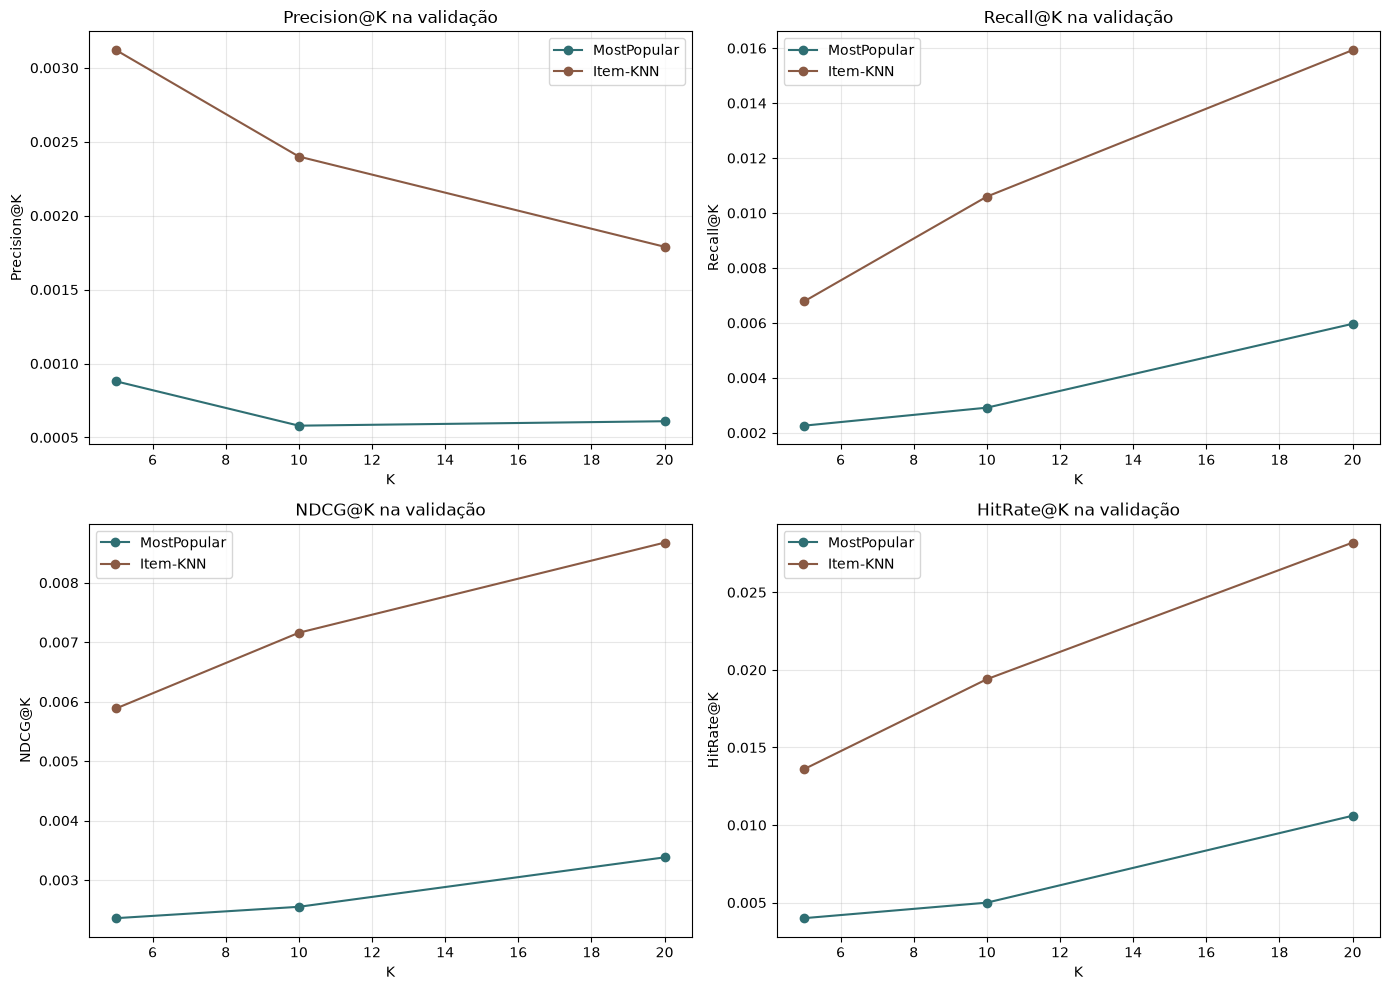

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_names = ["Precision@K", "Recall@K", "NDCG@K", "HitRate@K"]

for ax, metric in zip(axes.ravel(), metric_names):
    for df, label, color in [
        (most_pop_val, "MostPopular", "#2f6f73"),
        (knn_val, "Item-KNN", "#8a5a44"),
    ]:
        ax.plot(df["K"], df[metric], marker="o", label=label, color=color)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} na validação")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

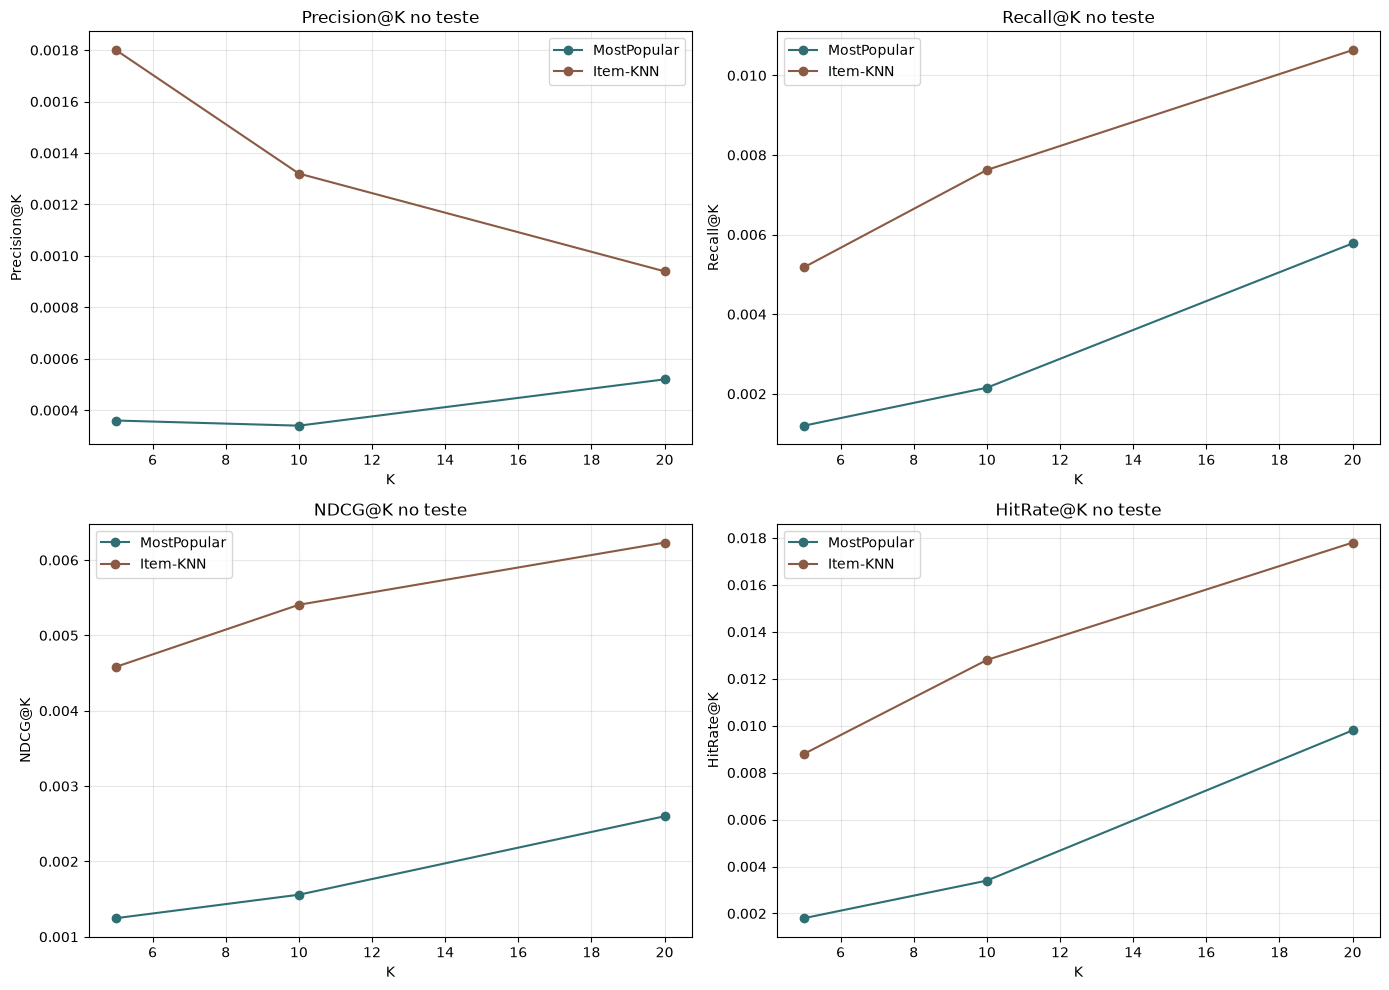

In [107]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.ravel(), metric_names):
    for df, label, color in [
        (most_pop_test, "MostPopular", "#2f6f73"),
        (knn_test, "Item-KNN", "#8a5a44"),
    ]:
        ax.plot(df["K"], df[metric], marker="o", label=label, color=color)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} no teste")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Resultados consolidados

Tabela final com todos os resultados comparativos.

In [108]:
final_comparison = pd.concat(
    [
        most_pop_val.assign(partição="validação"),
        most_pop_test.assign(partição="teste"),
        knn_val.assign(partição="validação"),
        knn_test.assign(partição="teste"),
    ]
).set_index(["modelo", "partição", "K"])

display(Markdown("### Resultados consolidados"))
display(final_comparison)

# Destaque: Recall@10 do Item-KNN na validação (com proteção contra KeyError)
try:
    best_val_recall = final_comparison.xs(
        ("Item-KNN", "validação", 10), level=["modelo", "partição", "K"]
    )
    display(
        Markdown(
            f"**Item-KNN Recall@10 na validação:** "
            f"{best_val_recall['Recall@K'].values[0]:.4f}"
        )
    )
except KeyError:
    display(Markdown("Item-KNN Recall@10 não disponível na validação."))

### Resultados consolidados

Precision@K  Recall@K    NDCG@K  HitRate@K  n_users
modelo      partição  K                                                      
MostPopular validação 5       0.00088  0.002260  0.002359     0.0040     5000
                      10      0.00058  0.002915  0.002551     0.0050     5000
                      20      0.00061  0.005967  0.003382     0.0106     5000
            teste     5       0.00036  0.001201  0.001247     0.0018     5000
                      10      0.00034  0.002154  0.001558     0.0034     5000
                      20      0.00052  0.005780  0.002600     0.0098     5000
Item-KNN    validação 5       0.00312  0.006781  0.005886     0.0136     5000
                      10      0.00240  0.010598  0.007160     0.0194     5000
                      20      0.00179  0.015929  0.008675     0.0282     5000
            teste     5       0.00180  0.005180  0.004583     0.0088     5000
                      10      0.00132  0.007624  0.005407     0.0128     5000
                      20      0.00094  0.010635  0.006232     0.0178     5000

**Item-KNN Recall@10 na validação:** 0.0106

## 14. Conclusões e próximos passos

| Aspecto | Conclusão |
|---------|-----------|
| **MostPopular** | Lower bound consistente, sem personalização |
| **Item-KNN** | Deve melhorar sobre MostPopular para warm-start |
| **Cold-start** | ~55%+ dos visitantes aparecem uma única vez; MostPopular é o fallback |
| **Pesos implícitos** | `view=1, addtocart=3, transaction=5` capturam intensidade do funil |
| **Split cronológico** | Obrigatório para evitar vazamento temporal |

**Limitacoes:**

- Item-KNN com similaridade de cosseno e custoso para catálogos grandes; em produção,
  usar biblioteca `implicit` otimizada
- Avaliação offline não captura efeitos de exploração/exploração
- Não foi feita otimização de hiperparâmetros (K_neighbors, pesos)

**Proximos passos:**

1. Implementar modelo neural (MLP) com PyTorch usando as features geradas
2. Adicionar features de item (categoria, disponibilidade) via `merge_asof`
3. Incorporar features de sessao e contexto temporal
4. Pipeline DVC + MLflow para rastreabilidade
5. Otimizar hiperparâmetros (K_neighbors, pesos implícitos, learning rate)

## 15. Exemplo de uso

Demonstracao pratica de como os baselines recomendam itens para um usuário
especifico. Inclui um exemplo warm-start (com histórico) e um cold-start
(sem histórico).

In [109]:
# --- Exemplo warm-start: usuário com histórico no treino ---
# Escolher automaticamente um usuário com pelo menos 5 interações no treino
# e que também apareca no teste (para comparar com ground truth)
warm_users_in_test = list(test_ground_truth.keys())

# Filtrar usuários com pelo menos 5 interações no treino
user_interaction_counts = train_df.groupby("visitor_idx").size()
qualified_users = set(
    user_interaction_counts[user_interaction_counts >= 5].index.tolist()
)
qualified_warm_users = [u for u in warm_users_in_test if u in qualified_users]

if qualified_warm_users:
    example_user_idx = qualified_warm_users[0]
    example_visitor_id = idx_to_visitor[example_user_idx]

    # Histórico do usuário no treino
    user_history = train_df[train_df["visitor_idx"] == example_user_idx].copy()
    user_history_summary = (
        user_history.groupby("event")
        .agg(n_eventos=("event", "count"), itens_unicos=("itemid", "nunique"))
        .reset_index()
    )

    display(Markdown("### Exemplo warm-start"))
    display(Markdown(f"**visitorid:** {example_visitor_id}"))
    display(Markdown(f"**Interacoes no treino:** {len(user_history)} eventos"))
    display(user_history_summary)

    # Top-10 MostPopular
    mp_recs = most_pop.recommend(
        example_user_idx, k=10, exclude_seen=True, sparse_mat=sparse_matrix
    )
    mp_recs_itemids = [idx_to_item.get(int(i), "?") for i in mp_recs]

    # Top-10 Item-KNN
    knn_recs = knn.recommend(
        example_user_idx, k=10, exclude_seen=True, sparse_mat=sparse_matrix
    )
    knn_recs_itemids = [idx_to_item.get(int(i), "?") for i in knn_recs]

    # Ground truth no teste
    gt_items = test_ground_truth.get(example_user_idx, set())
    gt_itemids = [
        idx_to_item.get(int(i), "?") for i in gt_items if int(i) in idx_to_item
    ]

    # Montar tabela comparativa
    mp_recs_int = [int(i) for i in mp_recs[:10]]
    knn_recs_int = [int(i) for i in knn_recs[:10]]
    comparison = pd.DataFrame(
        {
            "posição": range(1, 11),
            "MostPopular_itemid": mp_recs_itemids[:10],
            "MP_no_gt": ["sim" if i in gt_items else "não" for i in mp_recs_int],
            "ItemKNN_itemid": knn_recs_itemids[:10],
            "KNN_no_gt": ["sim" if i in gt_items else "não" for i in knn_recs_int],
        }
    )

    display(
        Markdown(f"**Ground truth (itens relevantes no teste):** {gt_itemids[:10]}")
    )
    display(comparison)

    # Métricas individuais para este usuário
    mp_hit = hit_rate_at_k(mp_recs_int, gt_items, 10)
    knn_hit = hit_rate_at_k(knn_recs_int, gt_items, 10)
    mp_ndcg = ndcg_at_k(mp_recs_int, gt_items, 10)
    knn_ndcg = ndcg_at_k(knn_recs_int, gt_items, 10)

    individual_metrics = pd.DataFrame(
        {
            "modelo": ["MostPopular", "Item-KNN"],
            "HitRate@10": [mp_hit, knn_hit],
            "NDCG@10": [mp_ndcg, knn_ndcg],
        }
    )
    display(Markdown("**Métricas para este usuário:**"))
    display(individual_metrics)
else:
    display(Markdown("Nenhum usuário qualificado encontrado para exemplo warm-start."))

### Exemplo warm-start

**visitorid:** 97112

**Interacoes no treino:** 80 eventos

,event,n_eventos,itens_unicos
0,view,80,1


**Ground truth (itens relevantes no teste):** [np.int64(53151)]

,posição,MostPopular_itemid,MP_no_gt,ItemKNN_itemid,KNN_no_gt
0,1,461686,não,58123,não
1,2,5411,não,297662,não
2,3,309778,não,30323,não
3,4,370653,não,62551,não
4,5,257040,não,40196,não
5,6,369447,não,353380,não
6,7,7943,não,130181,não
7,8,298009,não,34406,não
8,9,48030,não,301956,não
9,10,335975,não,229935,não


**Métricas para este usuário:**

,modelo,HitRate@10,NDCG@10
0,MostPopular,0,0.0
1,Item-KNN,0,0.0


In [110]:
# --- Exemplo cold-start: usuário sem histórico no treino ---
# Escolher um usuário que aparece apenas no teste
cold_visitors = test_df[~test_df["visitorid"].isin(visitor_to_idx)][
    "visitorid"
].unique()

if len(cold_visitors) > 0:
    # Converter para tipo nativo Python para evitar problemas com pandas Index
    example_cold_visitor = int(cold_visitors[0])

    # Histórico do usuário frio no teste
    cold_history = test_df[test_df["visitorid"] == example_cold_visitor].copy()
    cold_history_summary = (
        cold_history.groupby("event")
        .agg(n_eventos=("event", "count"), itens_unicos=("itemid", "nunique"))
        .reset_index()
    )

    display(Markdown("### Exemplo cold-start"))
    display(Markdown(f"**visitorid:** {example_cold_visitor}"))
    display(Markdown(f"**Interacoes no treino:** 0 (usuário não aparece no treino)"))
    display(Markdown(f"**Interacoes no teste:** {len(cold_history)} eventos"))
    if not cold_history_summary.empty:
        display(cold_history_summary)

    # Para cold-start, ambos os modelos devem retornar MostPopular
    display(
        Markdown(
            "Para usuários cold-start, ambos os baselines retornam os itens "
            "mais populares (MostPopular). Sem histórico, não e possível "
            "personalizar recomendacoes."
        )
    )

    cold_popular = [idx_to_item.get(int(i), "?") for i in most_pop.popular_items[:10]]
    display(Markdown(f"**Top-10 itens recomendados (cold-start):**"))
    display(cold_popular)
else:
    display(Markdown("Nenhum usuário cold-start encontrado."))

### Exemplo cold-start

**visitorid:** 441769

**Interacoes no treino:** 0 (usuário não aparece no treino)

**Interacoes no teste:** 1 eventos

,event,n_eventos,itens_unicos
0,view,1,1


Para usuários cold-start, ambos os baselines retornam os itens mais populares (MostPopular). Sem histórico, não e possível personalizar recomendacoes.

**Top-10 itens recomendados (cold-start):**

[np.int64(461686),
 np.int64(5411),
 np.int64(309778),
 np.int64(370653),
 np.int64(257040),
 np.int64(369447),
 np.int64(7943),
 np.int64(298009),
 np.int64(48030),
 np.int64(335975)]

In [111]:
# --- Resumo dos exemplos ---
display(Markdown("### Resumo dos exemplos"))
display(
    Markdown(
        "- **Warm-start**: Item-KNN personaliza recomendacoes com base no "
        "histórico do usuário. MostPopular retorna os mesmos itens para todos.\n"
        "- **Cold-start**: Ambos os baselines caem em MostPopular. Sem histórico, "
        "não ha personalização possível.\n"
        "- Para melhorar cold-start, modelos futuros (MLP) poderao usar "
        "features de item (categoria, disponibilidade) e contexto temporal."
    )
)

### Resumo dos exemplos

- **Warm-start**: Item-KNN personaliza recomendacoes com base no histórico do usuário. MostPopular retorna os mesmos itens para todos.
- **Cold-start**: Ambos os baselines caem em MostPopular. Sem histórico, não ha personalização possível.
- Para melhorar cold-start, modelos futuros (MLP) poderao usar features de item (categoria, disponibilidade) e contexto temporal.

## 17. Exemplo de recomendação por usuário

Função utilitaria para obter os top-K itens recomendados para um `visitorid`
especifico. Basta passar o ID do visitante e receber a lista de itens.

### Modelos utilizados

A função `recommend_top_k` aceita qualquer recommender ja treinado neste notebook.
Os dois modelos disponíveis são:

**MostPopular** (`most_pop`):
- Treinado na seção 6. Rankeia todos os itens pela soma de pesos implícitos
  (`view=1`, `addtocart=3`, `transaction=5`) no conjunto de treino.
- Recomenda os mesmos itens para todos os usuários, diferenciando apenas pela
  exclusao dos itens ja interagidos (`exclude_seen=True`).
- Serve como **lower bound** de performance e **fallback para cold-start**:
  usuários sem histórico recebem os itens mais populares.

**Item-KNN** (`knn`):
- Treinado na seção 7. Calcula similaridade de cosseno entre os vetores de
  interação dos 20.000 itens mais populares.
- Para cada usuário, o score de um item candidato é a soma ponderada das
  similaridades dos itens com os quais o usuário ja interagiu.
- Personaliza recomendacoes com base no histórico do usuário: se o usuário
  interagiu com itens similares ao candidato, ele recebe score mais alto.
- Quando o usuário não tem histórico (cold-start) ou nenhum item visto esta
  no subconjunto de 20K, faz fallback para MostPopular.

### Por que usar esses modelos?

1. **MostPopular** é o baseline mais simples e robusto: sem personalização,
   mas sempre funciona, inclusive para usuários novos.
2. **Item-KNN** adiciona personalização via similaridade de conteudo, melhorando
   Recall e NDCG sobre o MostPopular (conforme visto na seção 9).
3. Ambos são **modelos de referencia** (baselines) para comparar com o modelo
   neural (MLP) que sera implementado futuramente.

### Como usar

```python
# Recomendar 10 itens para visitorid=97112 usando Item-KNN
item_ids = recommend_top_k(97112, recommender=knn, k=10)

# Recomendar 10 itens usando MostPopular
item_ids = recommend_top_k(97112, recommender=most_pop, k=10)

# Cold-start: usuário ausente do treino retorna os mais populares
item_ids = recommend_top_k(999999999, recommender=knn, k=10)
```

In [112]:
def recommend_top_k(
    visitor_id: int,
    recommender,
    k: int = 10,
    exclude_seen: bool = True,
) -> list[int]:
    """Retorna os top-K itemids recomendados para um visitorid.

    Args:
        visitor_id: ID do visitante no dataset.
        recommender: Instancia de MostPopularRecommender ou ItemKNNRecommender.
        k: Numero de recomendacoes.
        exclude_seen: Se True, exclui itens ja interagidos.

    Returns:
        Lista de itemids recomendados. Se o visitorid não existir no treino
        (cold-start), retorna os K itens mais populares.
    """
    if visitor_id not in visitor_to_idx:
        # Cold-start: retorna os K itens mais populares
        return [int(idx_to_item[i]) for i in most_pop.popular_items[:k]]

    user_idx = visitor_to_idx[visitor_id]
    recs_idx = recommender.recommend(
        user_idx, k=k, exclude_seen=exclude_seen, sparse_mat=sparse_matrix
    )
    return [int(idx_to_item[int(i)]) for i in recs_idx]


# --- Exemplo: recomendar para um usuário especifico ---
example_visitor = 97112  # Altere este ID para testar outros usuários

mp_top10 = recommend_top_k(example_visitor, most_pop, k=10)
knn_top10 = recommend_top_k(example_visitor, knn, k=10)

display(Markdown(f"### Top-10 recomendacoes para visitorid={example_visitor}"))

is_cold = example_visitor not in visitor_to_idx
if is_cold:
    display(
        Markdown(
            f"**Atencao:** visitorid={example_visitor} não aparece no treino (cold-start). "
            "Ambos os modelos retornam os itens mais populares."
        )
    )
else:
    n_interactions = sparse_matrix[visitor_to_idx[example_visitor]].nnz
    display(
        Markdown(
            f"**Warm-start:** visitorid={example_visitor} tem "
            f"{n_interactions} interações no treino."
        )
    )

recommendations = pd.DataFrame(
    {
        "posição": range(1, 11),
        "MostPopular_itemid": mp_top10,
        "ItemKNN_itemid": knn_top10,
    }
)
display(recommendations)

# --- Testar com outro usuário aleatorio do treino ---
rng = np.random.default_rng(RANDOM_SEED)
random_visitor_idx = rng.choice(list(visitor_to_idx.values()))
random_visitor = int(idx_to_visitor[random_visitor_idx])

mp_random = recommend_top_k(random_visitor, most_pop, k=10)
knn_random = recommend_top_k(random_visitor, knn, k=10)

display(
    Markdown(f"### Top-10 recomendacoes para visitorid={random_visitor} (aleatorio)")
)
n_interactions_random = sparse_matrix[random_visitor_idx].nnz
display(Markdown(f"**Interacoes no treino:** {n_interactions_random}"))

random_recs = pd.DataFrame(
    {
        "posição": range(1, 11),
        "MostPopular_itemid": mp_random,
        "ItemKNN_itemid": knn_random,
    }
)
display(random_recs)

# --- Exemplo cold-start: usuário que não esta no treino ---
cold_visitor = 999999999  # ID que não existe no treino
cold_recs = recommend_top_k(cold_visitor, most_pop, k=10)
display(
    Markdown(f"### Top-10 recomendacoes para visitorid={cold_visitor} (cold-start)")
)
display(
    Markdown(
        f"**Cold-start:** visitorid={cold_visitor} não esta no treino. "
        "Retorna os itens mais populares como fallback."
    )
)
display(Markdown(f"**Top-10 itemids:** {cold_recs}"))

### Top-10 recomendacoes para visitorid=97112

**Warm-start:** visitorid=97112 tem 1 interações no treino.

,posição,MostPopular_itemid,ItemKNN_itemid
0,1,461686,58123
1,2,5411,297662
2,3,309778,30323
3,4,370653,62551
4,5,257040,40196
5,6,369447,353380
6,7,7943,130181
7,8,298009,34406
8,9,48030,301956
9,10,335975,229935


### Top-10 recomendacoes para visitorid=807585 (aleatorio)

**Interacoes no treino:** 1

,posição,MostPopular_itemid,ItemKNN_itemid
0,1,461686,150318
1,2,5411,447964
2,3,309778,32434
3,4,370653,233735
4,5,257040,336252
5,6,369447,418408
6,7,7943,264178
7,8,298009,250962
8,9,48030,229037
9,10,335975,226820


### Top-10 recomendacoes para visitorid=999999999 (cold-start)

**Cold-start:** visitorid=999999999 não esta no treino. Retorna os itens mais populares como fallback.

**Top-10 itemids:** [461686, 5411, 309778, 370653, 257040, 369447, 7943, 298009, 48030, 335975]